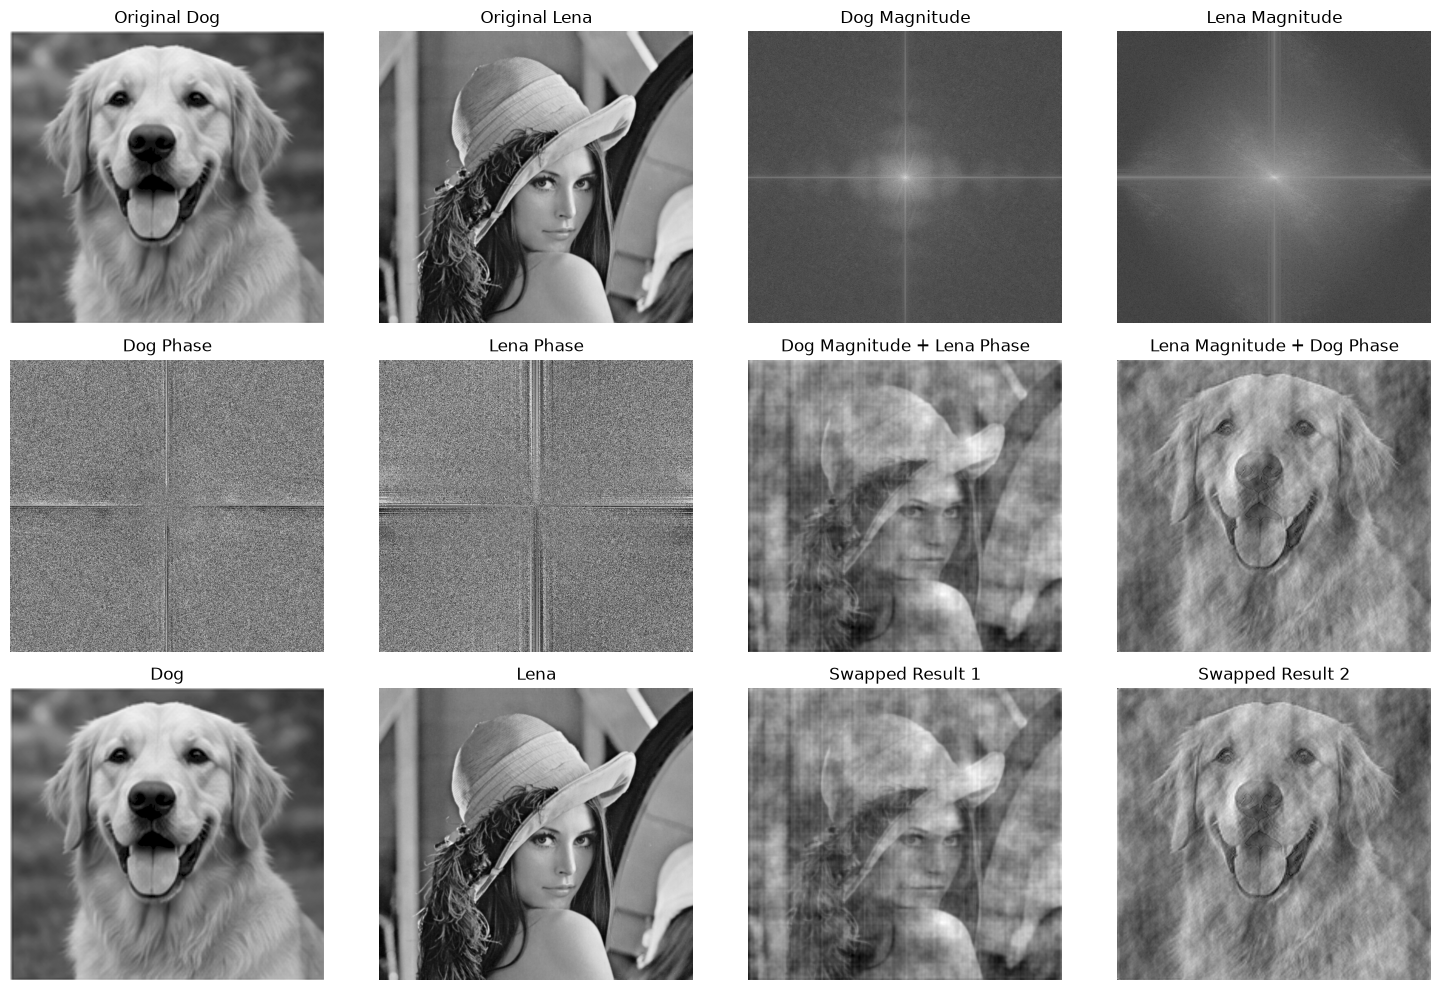

Magnitude-Phase Swapping Completed
Output 1 : dog_magnitude_lena_phase.png
Output 2 : lena_magnitude_dog_phase.png


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

DOG_PATH = "./dog.png"
LENA_PATH = "./lena.png"

dog = cv2.imread(DOG_PATH, cv2.IMREAD_GRAYSCALE)
lena = cv2.imread(LENA_PATH, cv2.IMREAD_GRAYSCALE)

if dog is None:
    raise FileNotFoundError(f"Could not find image: {DOG_PATH}")

if lena is None:
    raise FileNotFoundError(f"Could not find image: {LENA_PATH}")

height, width = dog.shape

lena = cv2.resize(lena, (width, height))


# Convert to floating point
dog = dog.astype(np.float64)
lena = lena.astype(np.float64)

F_dog = np.fft.fft2(dog)
F_lena = np.fft.fft2(lena)

F_dog_shifted = np.fft.fftshift(F_dog)
F_lena_shifted = np.fft.fftshift(F_lena)
dog_magnitude = np.abs(F_dog_shifted)
lena_magnitude = np.abs(F_lena_shifted)


dog_phase = np.angle(F_dog_shifted)
lena_phase = np.angle(F_lena_shifted)
# Image 1:
# Dog magnitude + Lena phase
swapped_dog = dog_magnitude * np.exp(1j * lena_phase)

# Image 2:
# Lena magnitude + Dog phase
swapped_lena = lena_magnitude * np.exp(1j * dog_phase)


swapped_dog_unshifted = np.fft.ifftshift(swapped_dog)
swapped_lena_unshifted = np.fft.ifftshift(swapped_lena)


# Inverse FFT
reconstructed_dog = np.fft.ifft2(swapped_dog_unshifted)
reconstructed_lena = np.fft.ifft2(swapped_lena_unshifted)


# Only the real part is required because the original image
# is real-valued.
reconstructed_dog = np.real(reconstructed_dog)
reconstructed_lena = np.real(reconstructed_lena)


# ============================================================
# 7. NORMALIZE RESULTS FOR DISPLAY
# ============================================================

reconstructed_dog = cv2.normalize(
    reconstructed_dog,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

reconstructed_lena = cv2.normalize(
    reconstructed_lena,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


plt.figure(figsize=(15, 10))

plt.subplot(3, 4, 1)
plt.imshow(dog, cmap="gray")
plt.title("Original Dog")
plt.axis("off")

plt.subplot(3, 4, 2)
plt.imshow(lena, cmap="gray")
plt.title("Original Lena")
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(np.log1p(dog_magnitude), cmap="gray")
plt.title("Dog Magnitude")
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(np.log1p(lena_magnitude), cmap="gray")
plt.title("Lena Magnitude")
plt.axis("off")


plt.subplot(3, 4, 5)
plt.imshow(dog_phase, cmap="gray")
plt.title("Dog Phase")
plt.axis("off")

plt.subplot(3, 4, 6)
plt.imshow(lena_phase, cmap="gray")
plt.title("Lena Phase")
plt.axis("off")


plt.subplot(3, 4, 7)
plt.imshow(reconstructed_dog, cmap="gray")
plt.title("Dog Magnitude + Lena Phase")
plt.axis("off")

plt.subplot(3, 4, 8)
plt.imshow(reconstructed_lena, cmap="gray")
plt.title("Lena Magnitude + Dog Phase")
plt.axis("off")

plt.subplot(3, 4, 9)
plt.imshow(dog, cmap="gray")
plt.title("Dog")
plt.axis("off")

plt.subplot(3, 4, 10)
plt.imshow(lena, cmap="gray")
plt.title("Lena")
plt.axis("off")

plt.subplot(3, 4, 11)
plt.imshow(reconstructed_dog, cmap="gray")
plt.title("Swapped Result 1")
plt.axis("off")

plt.subplot(3, 4, 12)
plt.imshow(reconstructed_lena, cmap="gray")
plt.title("Swapped Result 2")
plt.axis("off")

plt.tight_layout()
plt.show()


cv2.imwrite("dog_magnitude_lena_phase.png", reconstructed_dog)
cv2.imwrite("lena_magnitude_dog_phase.png", reconstructed_lena)

print("==============================================")
print("Magnitude-Phase Swapping Completed")
print("==============================================")
print("Output 1 : dog_magnitude_lena_phase.png")
print("Output 2 : lena_magnitude_dog_phase.png")